In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import joblib
from pathlib import Path
import matplotlib.pyplot as plt

## 1. Load Preprocessed Data (v2)

In [ ]:
# Load corrected monthly data
data_path = Path('../Preprocessed_dataset/algiers_monthly_processed_v2.csv')
df = pd.read_csv(data_path, parse_dates=['date'])
df = df.set_index('date').asfreq('MS')

# Extract temperature series
temp_series = df['temperature_2m_mean'].copy().fillna(method='ffill')

print(f"Data loaded: {len(temp_series)} months from {temp_series.index.min()} to {temp_series.index.max()}")

📊 Data loaded: 260 months from 2002-01-01 00:00:00 to 2023-08-01 00:00:00


C:\Users\hp probook\AppData\Local\Temp\ipykernel_6304\1663357595.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temp_series = df['temperature_2m_mean'].copy().fillna(method='ffill')


## 2. Feature Engineering for Linear Model

Create:
- Time trend (months since start)
- Seasonal dummies (12 months)

In [4]:
def create_features(dates):
    """Create time trend + seasonal features from dates"""
    df_feat = pd.DataFrame(index=dates)
    
    # Time trend (months since first observation)
    df_feat['time_trend'] = np.arange(len(dates))
    
    # Seasonal dummies (month of year)
    for month in range(1, 13):
        df_feat[f'month_{month}'] = (dates.month == month).astype(int)
    
    return df_feat

# Create features for training
X_train = create_features(temp_series.index)
y_train = temp_series.values

print(f"Features created: {X_train.shape}")
print(X_train.head())

Features created: (260, 13)
            time_trend  month_1  month_2  month_3  month_4  month_5  month_6  \
date                                                                           
2002-01-01           0        1        0        0        0        0        0   
2002-02-01           1        0        1        0        0        0        0   
2002-03-01           2        0        0        1        0        0        0   
2002-04-01           3        0        0        0        1        0        0   
2002-05-01           4        0        0        0        0        1        0   

            month_7  month_8  month_9  month_10  month_11  month_12  
date                                                                 
2002-01-01        0        0        0         0         0         0  
2002-02-01        0        0        0         0         0         0  
2002-03-01        0        0        0         0         0         0  
2002-04-01        0        0        0         0         0    

## 3. Fit Linear Model on Full Dataset

In [5]:
# Standardize features for better numerical stability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Fit linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Training performance
train_score = model.score(X_train_scaled, y_train)
print(f"Model fitted! R² on training data: {train_score:.4f}")

# Display coefficients
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 5 most important features:")
print(coef_df.head())

Model fitted! R² on training data: 0.9652

Top 5 most important features:
     feature  coefficient
8    month_8     2.372135
7    month_7     2.321799
1    month_1    -2.010708
2    month_2    -1.889145
12  month_12    -1.610811


## 4. Forecast to December 2040

In [6]:
# Calculate forecast horizon
last_date = temp_series.index.max()
target_date = pd.Timestamp('2040-12-01')
n_periods = (target_date.year - last_date.year) * 12 + (target_date.month - last_date.month)

if n_periods <= 0:
    raise ValueError(f"Target date {target_date} is not after last observation {last_date}")

print(f"Forecasting {n_periods} months from {last_date} to {target_date}")

# Create future dates and features
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_periods, freq='MS')
X_future = create_features(forecast_index)

# Important: continue time trend from training
X_future['time_trend'] = np.arange(len(temp_series), len(temp_series) + n_periods)

# Scale and predict
X_future_scaled = scaler.transform(X_future)
forecast = model.predict(X_future_scaled)

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'date': forecast_index,
    'temperature_forecast': forecast
})

print("\nForecast preview:")
print(forecast_df.head())
print("...")
print(forecast_df.tail())

Forecasting 208 months from 2023-08-01 00:00:00 to 2040-12-01 00:00:00

Forecast preview:
        date  temperature_forecast
0 2023-09-01             24.117475
1 2023-10-01             20.622190
2 2023-11-01             15.593189
3 2023-12-01             12.609594
4 2024-01-01             11.301715
...
          date  temperature_forecast
203 2040-08-01             28.086282
204 2040-09-01             25.179935
205 2040-10-01             21.684651
206 2040-11-01             16.655650
207 2040-12-01             13.672055


## 5. Visualize Forecast

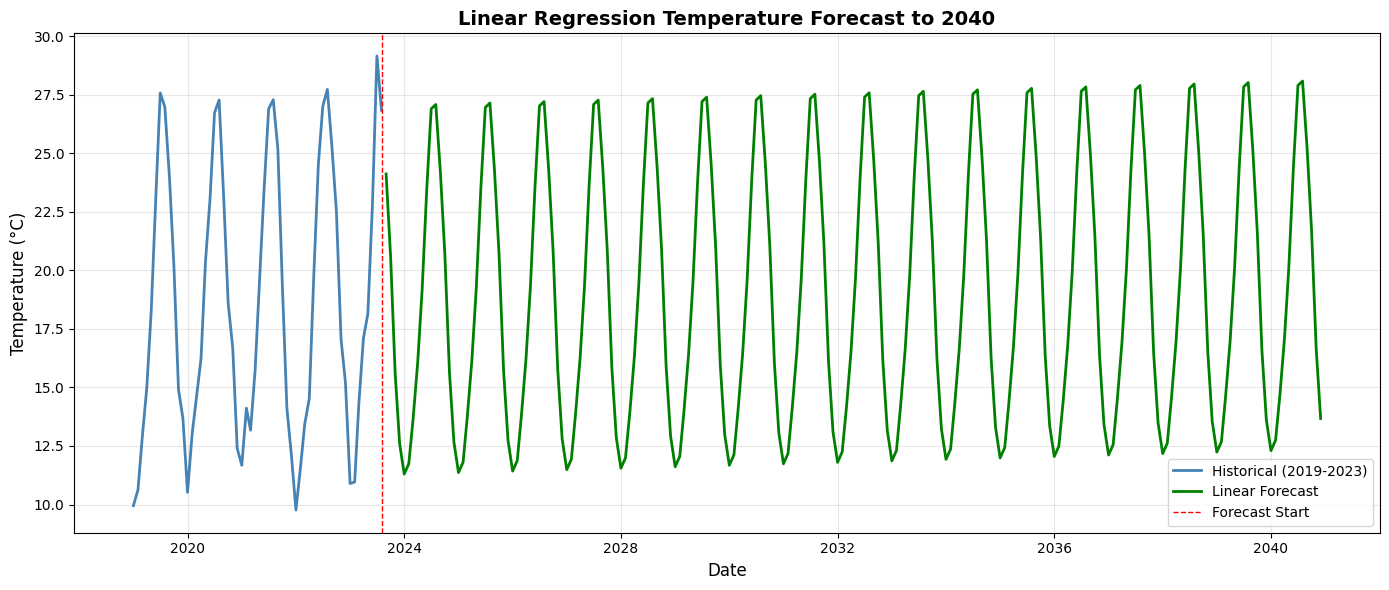

Plot saved to Results/linear_forecast_plot.png


In [7]:
# Plot historical + forecast
plt.figure(figsize=(14, 6))

# Historical data (last 5 years)
recent_history = temp_series.loc['2019':]
plt.plot(recent_history.index, recent_history.values, label='Historical (2019-2023)', color='steelblue', linewidth=2)

# Forecast
plt.plot(forecast_df['date'], forecast_df['temperature_forecast'], label='Linear Forecast', color='green', linewidth=2)

plt.axvline(last_date, color='red', linestyle='--', linewidth=1, label='Forecast Start')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Linear Regression Temperature Forecast to 2040', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Results/linear_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print('Plot saved to Results/linear_forecast_plot.png')

## 6. Save Model & Forecast

In [8]:
# Save forecast CSV
forecast_path = Path('../Predictions/linear_forecast_2040_final.csv')
forecast_df.to_csv(forecast_path, index=False)
print(f"Forecast saved to: {forecast_path}")

# Save model + scaler
model_artifacts = {
    'model': model,
    'scaler': scaler,
    'feature_names': X_train.columns.tolist(),
    'last_time_index': len(temp_series)
}
model_path = Path('../Models/linear_model_final.pkl')
joblib.dump(model_artifacts, model_path)
print(f"Model saved to: {model_path}")

print('\nLinear pipeline complete!')

Forecast saved to: ..\Predictions\linear_forecast_2040_final.csv
Model saved to: ..\Models\linear_model_final.pkl

Linear pipeline complete!


## Summary Statistics

In [9]:
print("Forecast Summary:")
print(f"Mean forecast temperature: {forecast_df['temperature_forecast'].mean():.2f}°C")
print(f"Min forecast: {forecast_df['temperature_forecast'].min():.2f}°C")
print(f"Max forecast: {forecast_df['temperature_forecast'].max():.2f}°C")
print(f"Std deviation: {forecast_df['temperature_forecast'].std():.2f}°C")
print(f"\nLinear trend coefficient: {model.coef_[0]:.6f}°C per month (scaled)")

Forecast Summary:
Mean forecast temperature: 19.04°C
Min forecast: 11.30°C
Max forecast: 28.09°C
Std deviation: 5.60°C

Linear trend coefficient: 0.390897°C per month (scaled)
